🚀 OpsVision AI

📌 Objetivo
Analizar datos de entregas para entender qué factores afectan los tiempos y construir un modelo que prediga el tiempo estimado de entrega (ETA).```



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from google.colab import files
uploaded = files.upload()


Saving deliveries.csv to deliveries (1).csv


In [6]:
df = pd.read_csv("deliveries.csv")

In [14]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance       20 non-null     float64
 1   traffic        20 non-null     object 
 2   weather        20 non-null     object 
 3   delivery_time  20 non-null     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 772.0+ bytes


,distance,delivery_time
count,20.000000,20.000000
mean,5.455000,33.400000
std,2.850572,18.079939
min,1.200000,12.000000
25%,3.025000,17.500000
50%,5.250000,29.000000
75%,7.850000,45.750000
max,10.500000,70.000000


In [7]:
df.head()

,distance,traffic,weather,delivery_time
0,2.5,low,clear,15
1,5.0,medium,clear,25
2,7.2,high,rain,45
3,3.1,low,clear,18
4,10.5,high,storm,60


In [8]:
traffic_analysis = df.groupby("traffic")["delivery_time"].mean()
traffic_analysis

,delivery_time
traffic,
high,54.000000
low,15.428571
medium,30.333333


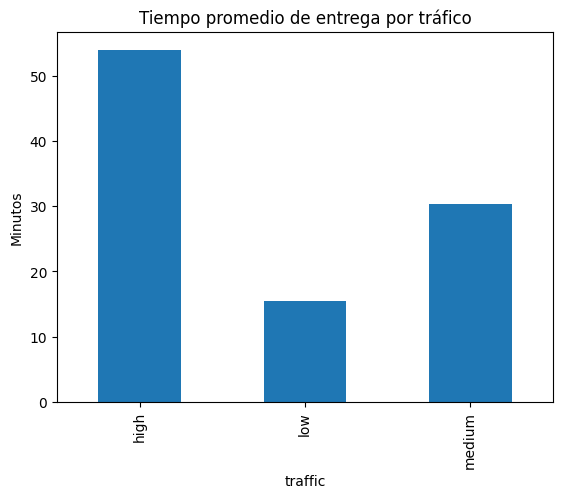

In [9]:
traffic_analysis.plot(kind="bar")
plt.title("Tiempo promedio de entrega por tráfico")
plt.ylabel("Minutos")
plt.show()

In [10]:
weather_analysis = df.groupby("weather")["delivery_time"].mean()
weather_analysis

,delivery_time
weather,
clear,20.636364
rain,41.600000
storm,58.250000


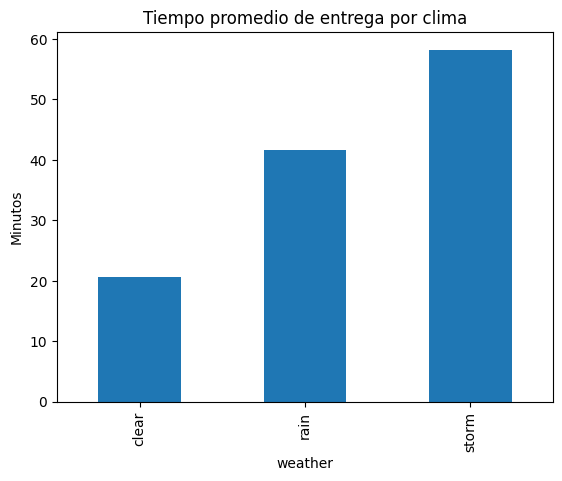

In [11]:
weather_analysis.plot(kind="bar")
plt.title("Tiempo promedio de entrega por clima")
plt.ylabel("Minutos")
plt.show()

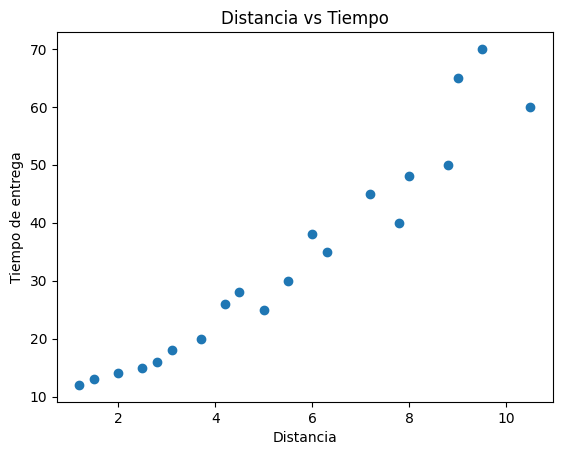

In [12]:
plt.scatter(df["distance"], df["delivery_time"])
plt.xlabel("Distancia")
plt.ylabel("Tiempo de entrega")
plt.title("Distancia vs Tiempo")
plt.show()


```
El tráfico alto tiene el mayor impacto en el tiempo de entrega
El clima (lluvia y tormenta) aumenta los retrasos
La distancia influye, pero no es el factor principal
Los peores escenarios ocurren cuando hay tráfico alto + mal clima
```





💼 Conclusión

Este análisis muestra que los retrasos no dependen solo de la distancia, sino principalmente de condiciones externas como el tráfico y el clima.

Esto significa que una empresa de delivery podría mejorar su operación si:

Ajusta recursos en zonas con alto tráfico
Considera el clima al estimar tiempos
Identifica pedidos con alto riesgo de retraso




In [13]:
df.groupby(["traffic", "weather"])["delivery_time"].mean()

traffic  weather
high     clear      40.000000
         rain       47.666667
         storm      65.000000
low      clear      15.428571
medium   clear      26.333333
         rain       32.500000
         storm      38.000000
Name: delivery_time, dtype: float64

La combinación de tráfico alto + lluvia genera los mayores tiempos de entrega”